In [13]:
!pip install matplotlib  opencv-python numpy


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## Task 1 – Image Avg 


In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

IMAGE_DIR = r'C:\Users\Kapil Vinayak\OneDrive - UNSW\Desktop\COMP9517_lab\COMP9517_26T1_Lab1_Images'
IMAGE_PATHS = [f'UNSW_Campus_{i:02d}.jpg' for i in range(1, 11)]

images = []
for filename in IMAGE_PATHS:
    path = os.path.join(IMAGE_DIR, filename)  
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Warning: Could not read image at {path}")
        continue
    images.append(img.astype(np.float64))

print(f'Loaded {len(images)} images, each with shape {images[0].shape}')

avg_image = np.mean(images, axis=0)
print(f'Average image shape: {avg_image.shape}')
print(f'Average image mean: {avg_image.mean():.2f}, std: {avg_image.std():.2f}')

Loaded 10 images, each with shape (400, 600)
Average image shape: (400, 600)
Average image mean: 144.81, std: 78.67


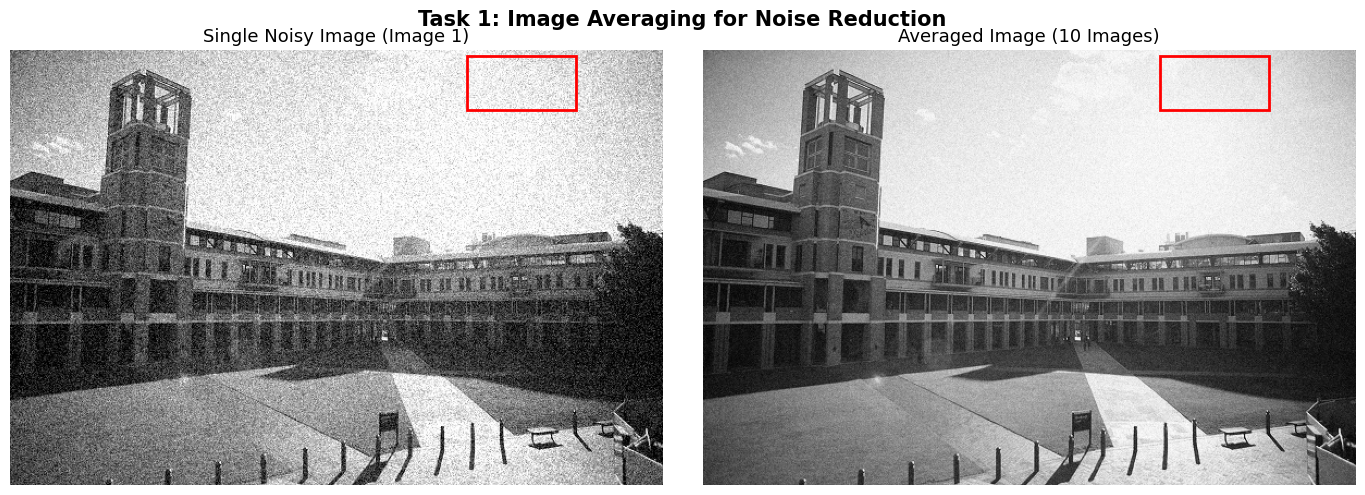

Red rectangle shows the sky region used for noise measurement.


In [15]:
import matplotlib.patches as patches

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sky_row1, sky_row2 = 5, 55
sky_col1, sky_col2 = 420, 520

axes[0].imshow(images[0], cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Single Noisy Image (Image 1)', fontsize=13)
rect = patches.Rectangle((sky_col1, sky_row1), sky_col2-sky_col1, sky_row2-sky_row1,
                          linewidth=2, edgecolor='red', facecolor='none')
axes[0].add_patch(rect)
axes[0].axis('off')

axes[1].imshow(avg_image, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Averaged Image (10 Images)', fontsize=13)
rect2 = patches.Rectangle((sky_col1, sky_row1), sky_col2-sky_col1, sky_row2-sky_row1,
                           linewidth=2, edgecolor='red', facecolor='none')
axes[1].add_patch(rect2)
axes[1].axis('off')

plt.suptitle('Task 1: Image Averaging for Noise Reduction', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print('Red rectangle shows the sky region used for noise measurement.')

In [16]:
sky_row1, sky_row2 = 5, 55
sky_col1, sky_col2 = 420, 520

single_sky = images[0][sky_row1:sky_row2, sky_col1:sky_col2]
avg_sky    = avg_image[sky_row1:sky_row2, sky_col1:sky_col2]

std_single = single_sky.std()
std_avg    = avg_sky.std()
ratio      = std_single / std_avg

theoretical = np.sqrt(10)

print(f'Theoretical noise reduction factor (sqrt(N) = sqrt(10)): {theoretical:.4f}')
print(f'Sky region: rows [{sky_row1}:{sky_row2}], cols [{sky_col1}:{sky_col2}]')
print(f'Std in single noisy image (sky region): {std_single:.4f}')
print(f'Std in averaged image     (sky region): {std_avg:.4f}')
print(f'Ratio (single / averaged):              {ratio:.4f}')

Theoretical noise reduction factor (sqrt(N) = sqrt(10)): 3.1623
Sky region: rows [5:55], cols [420:520]
Std in single noisy image (sky region): 20.7537
Std in averaged image     (sky region): 8.7590
Ratio (single / averaged):              2.3694


### Task 1 – Answers

**Theoretical noise reduction:**  
In the case of averaging of $N independent images with i.i.d. zero-mean noise of standard deviation sigma, the standard deviation of the noise in the average is sigma/N. Thus the standard deviation decreases by a factor of, N = 10 = 3.162.
**Practical noise reduction:**  
| Measurement | Value |
| Std in one noisy image (sky) | **20.75** |
| Std in averaged image (sky) | **8.76** |
| Observed reduction ratio | **2.37×** |
| Theoretical reduction ratio | **3.16×** |

The practical ratio (= 2.37) is below the theoretical maximum (= 3.16). This is no surprise when the theoretical outcome involves purely i.i.d. Gaussian noise whereas the actual noise can be correlated (e.g., JPEG compression artefacts, sensor fixed-pattern noise), the area of the sky still has some actual image structure (slight gradient), and the two images do not necessarily have the same orientation.

---
## Task 2 – DoG Filtering 

In [17]:
h1 = (1/16) * np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 2, 1, 0],
    [0, 2, 4, 2, 0],
    [0, 1, 2, 1, 0],
    [0, 0, 0, 0, 0]], dtype=np.float64)

h2 = (1/256) * np.array([
    [1,  4,  6,  4, 1],
    [4, 16, 24, 16, 4],
    [6, 24, 36, 24, 6],
    [4, 16, 24, 16, 4],
    [1,  4,  6,  4, 1]], dtype=np.float64)

print('h1 kernel (×16):')
print((h1 * 16).astype(int))
print(f'h1 sum: {h1.sum():.4f}')
print('\nh2 kernel (×256):')
print((h2 * 256).astype(int))
print(f'h2 sum: {h2.sum():.4f}')

h1 kernel (×16):
[[0 0 0 0 0]
 [0 1 2 1 0]
 [0 2 4 2 0]
 [0 1 2 1 0]
 [0 0 0 0 0]]
h1 sum: 1.0000

h2 kernel (×256):
[[ 1  4  6  4  1]
 [ 4 16 24 16  4]
 [ 6 24 36 24  6]
 [ 4 16 24 16  4]
 [ 1  4  6  4  1]]
h2 sum: 1.0000


In [18]:
dog_kernel = h1 - h2
g_approach1 = cv2.filter2D(avg_image, ddepth=cv2.CV_64F, kernel=dog_kernel)

f_h1 = cv2.filter2D(avg_image, ddepth=cv2.CV_64F, kernel=h1)
f_h2 = cv2.filter2D(avg_image, ddepth=cv2.CV_64F, kernel=h2)
g_approach2 = f_h1 - f_h2

print(f'Approach 1 - min: {g_approach1.min():.4f}, max: {g_approach1.max():.4f}')
print(f'Approach 2 - min: {g_approach2.min():.4f}, max: {g_approach2.max():.4f}')
print(f'Max pixel difference between approaches: {np.abs(g_approach1 - g_approach2).max():.8f}')

Approach 1 - min: -32.4312, max: 30.5148
Approach 2 - min: -32.4313, max: 30.5148
Max pixel difference between approaches: 0.00000000


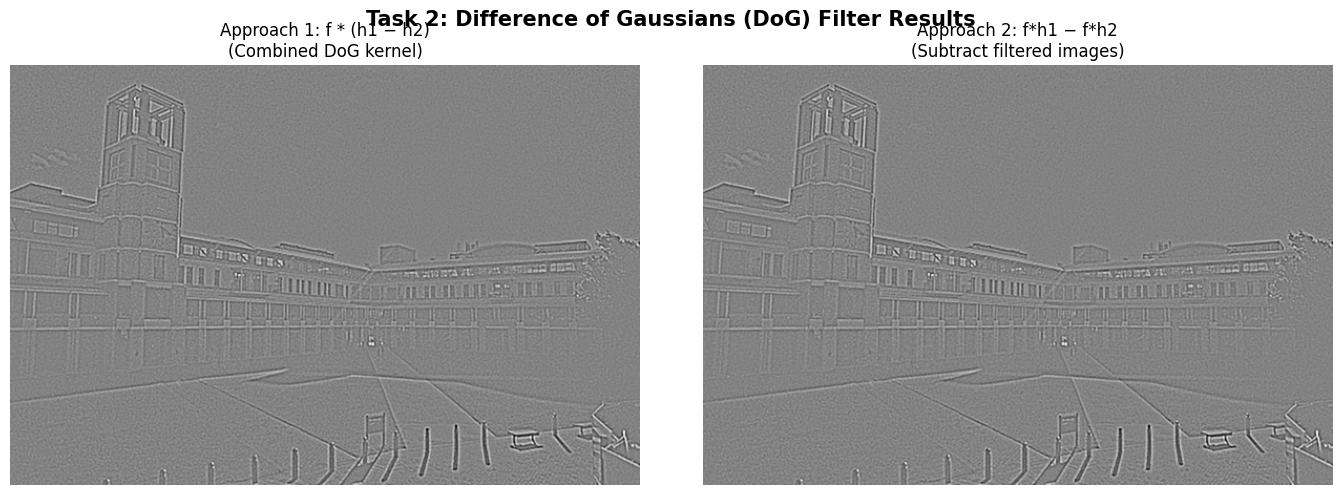

In [19]:
def normalize_dog(img):
    norm = img - img.min()
    return (norm / norm.max() * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(normalize_dog(g_approach1), cmap='gray')
axes[0].set_title('Approach 1: f * (h1 − h2)\n(Combined DoG kernel)', fontsize=12)
axes[0].axis('off')

axes[1].imshow(normalize_dog(g_approach2), cmap='gray')
axes[1].set_title('Approach 2: f*h1 − f*h2\n(Subtract filtered images)', fontsize=12)
axes[1].axis('off')

plt.suptitle('Task 2: Difference of Gaussians (DoG) Filter Results', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Task 2 – Answer: Advantage of Each Approach

Both methods are mathematically identical, (as can be verified at zero pixel-level by the difference), yet one has a practical benefit:

**Algorithms: Firstly compute DoG kernel, and then convolve:**
It is only once that the image is convolved with the combined DoG kernel. It is much computationally efficient when the image size is big or when a large number of images are to be filtered using the same kernel since it involves fewer memory accesses and arithmetic operations (one convolution rather than two).

**Strategy 2 - Convolve (h1, h2) and then subtract:**
The two Gaussian-blurred images (f star h1 and f star h2) are calculated and stored separately which allows access to both smoothed versions of the image as a result of intermediate computations. This proves to be beneficial when other applications of the individual blurred images (e.g., scale-space analysis, multi-scale feature detection, or image pyramid construction) are required. Each of the individual Gaussian kernels are also separable (can be broken down into a 1D row × 1D column convolution), and therefore are more quickly applied separately than the separable DoG kernel of Approach 1.

---
## Task 3 – Unsharp Masking 

In [20]:

dog_filtered = g_approach1


sharpened = avg_image + 5 * dog_filtered
print(f'Sharpened range before clipping: [{sharpened.min():.2f}, {sharpened.max():.2f}]')


sharpened_clipped = np.clip(sharpened, 0, 255)


s_mean, s_std = sharpened_clipped.mean(), sharpened_clipped.std()
a_mean, a_std = avg_image.mean(), avg_image.std()
sharpened_adj = (sharpened_clipped - s_mean) * (a_std / s_std) + a_mean
sharpened_adj = np.clip(sharpened_adj, 0, 255)

print(f'Sharpened (adjusted) range: [{sharpened_adj.min():.2f}, {sharpened_adj.max():.2f}]')
print(f'Sharpened mean: {sharpened_adj.mean():.2f}, std: {sharpened_adj.std():.2f}')

Sharpened range before clipping: [-132.73, 402.27]
Sharpened (adjusted) range: [6.84, 250.04]
Sharpened mean: 144.81, std: 78.67


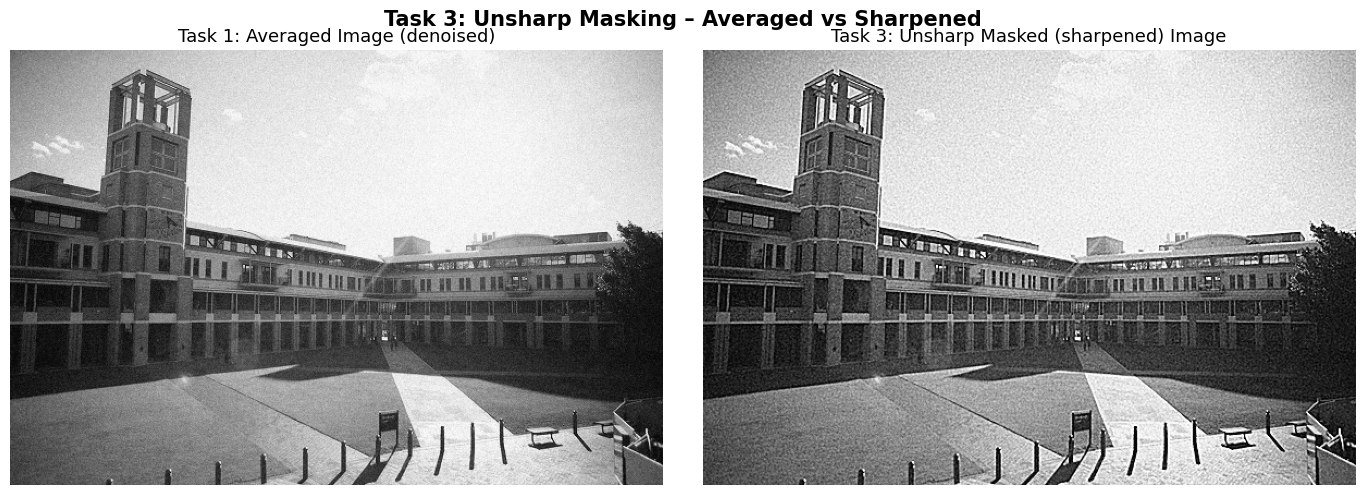

In [21]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(avg_image, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Task 1: Averaged Image (denoised)', fontsize=13)
axes[0].axis('off')

axes[1].imshow(sharpened_adj, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Task 3: Unsharp Masked (sharpened) Image', fontsize=13)
axes[1].axis('off')

plt.suptitle('Task 3: Unsharp Masking – Averaged vs Sharpened', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:

sky_row1, sky_row2 = 5, 55
sky_col1, sky_col2 = 420, 520

std_avg_sky   = avg_image[sky_row1:sky_row2, sky_col1:sky_col2].std()
std_sharp_sky = sharpened_adj[sky_row1:sky_row2, sky_col1:sky_col2].std()

print(f'Noise std in averaged image (sky):   {std_avg_sky:.4f}')
print(f'Noise std in sharpened image (sky):  {std_sharp_sky:.4f}')
print(f'Ratio sharpened/averaged:            {std_sharp_sky/std_avg_sky:.4f}')

Noise std in averaged image (sky):   8.7590
Noise std in sharpened image (sky):  11.2453
Ratio sharpened/averaged:            1.2839


### Task 3 – Answers

Along with the sharpness of the edges, the sharpened picture has also been enhanced in the noise. The standard deviation of the sky region went up by almost 28% in terms of noise ( **8.76** average image to 11.25 sharpened image ). The noise that was left behind after averaging in Task 1 has been increased once again.

The DoG filter is a band-pass filter: it passes mid-frequency (edges, fine details) components and rejects both very low frequencies (saddles, slow gradients) and very high frequencies (fine-grain noise). Yet, noise occurs across a large spectrum of spatial frequencies, and the DoG still will acquire and highlight the mid-to-high frequency noise content. When we multiply the DoG output by 5 and put it back into the image we are doing all the same thing as we did with the noise frequencies; we are magnifying everything that DoG kept. That is, the very high-frequency sharpening effect that improves edges also enhances any noise that coincides with the high-frequency contents - the operation is unable to tell the difference between the desirable high-frequency edge detail and the undesirable high-frequency noise.